# Assignment 1: Anomaly Detection
In this assignment you will be asked to implement **one** of the local outlier factor or isolation forest. You may pick which one you want to implement. For the other you may use a reference implementation from a public library to answer all questions.

In [61]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, matthews_corrcoef, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Local Outlier Factor
This first part of the assignment will consist of implementing the LOF from the ground up.

First, we need a dataset to work with, which is created below.

In [2]:
data, labels = make_blobs(n_samples=[100, 100, 2],random_state=42)

## Task: Understand the dataset
1. Shortly describe the dataset, and what you would expect the LOF to be of the different datapoints

## Answer
- Write your answers here

I expect the two clusters to be not outliers and have LOF ~ 1 as they are dense regions, while for k>1 the third cluster will likely be identified as an outlier (Lof>1) as they re sparse (LOF  compare the Local reachability density of a sample with its k neighbour). I'd avoid choosing k>100 (it would still work probably but it would pick neighburs from the other cluster which diluite the information and is needlessly expensive in computational terms)


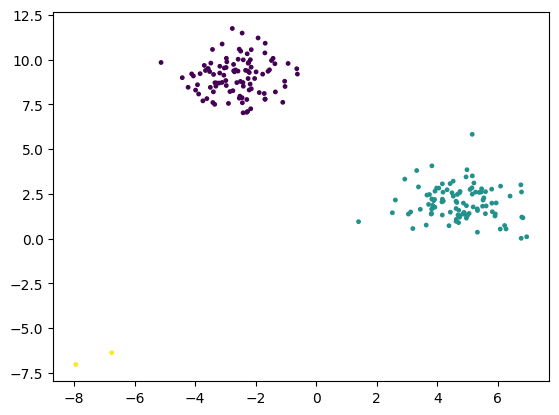

In [3]:
plt.scatter(data[:,0], data[:,1], c=labels, s=6)

## Task: implement the Local Outlier Factor
- Below are the signatures of all functions necessary for the Local Outlier Factor. Complete the implementations to fully implement the LOF.

In [4]:
def dist(x, y):
    """
    :x: point in the dataset, np.array
    :y: point in the dataset, np.array
    """
    return np.linalg.norm(x - y)

In [5]:
def k_dist(k, o, D):
    """
    :k: hyperparameter k of LOF
    :o: datapoint, np.array
    :D: complete dataset, np.array
    """
    distances = [dist(o, x) for x in D if not np.array_equal(o, x)]
    distances.sort()
    return distances[k - 1]

In [6]:
def N_k(k, o, D):
    """
    :k: hyperparameter k of LOF
    :o: datapoint, np.array
    :D: complete dataset, np.array
    """
    distances = []
    for x in D:
        if not np.array_equal(x, o):
            distances.append((x, dist(o, x)))

    distances.sort(key=lambda tup: tup[1])

    neighbors = [tup[0] for tup in distances[:k]]

    return np.array(neighbors)

In [7]:
def reach_dist(k, x, o, D):
    """
    :k: hyperparameter k of LOF
    :x: datapoint, np.array
    :o: datapoint, np.array
    :D: dataset, np.array
    """
    return max(k_dist(k, x, D), dist(o, x))

In [8]:
def lrd(k, o, D):
    """
    :k: hyperparameter k of LOF
    :o: datapoint, np.array
    :D: dataset, np.array
    """
    neighbors = N_k(k, o, D)
    reach_dists = [reach_dist(k, x, o, D) for x in neighbors]
    return len(neighbors) / np.sum(reach_dists)

In [9]:
def lof(k, o, D):
    """
    :k: hyperparameter k of LOF
    :o: datapoint, np.array
    :D: dataset, np.array
    """
    lrd_o = lrd(k, o, D)
    neighbors = N_k(k, o, D)
    lrd_ratios = [lrd(k, x, D) / lrd_o for x in neighbors]
    return np.sum(lrd_ratios) / len(neighbors)

### Below is some helper code so you can compare your results with the LOF of the popular library scikit-learn

In [10]:
from sklearn.neighbors import LocalOutlierFactor

In [11]:
# it should work for all values of k of course
k = 5

In [12]:
my_lof_scores = np.array([lof(k, o, data) for o in data])
print(my_lof_scores[:10])

[1.03854434 1.03759892 0.94794951 1.09736105 0.98664123 1.74905378
 1.03064327 1.04210801 2.1033075  0.9904549 ]


In [13]:
sk_lof = LocalOutlierFactor(n_neighbors=k)
sk_lof.fit_predict(data)
sk_lof_scores = np.negative(sk_lof.negative_outlier_factor_)
print(sk_lof_scores[:10])

[1.03854434 1.03759892 0.94794951 1.09736105 0.98664123 1.74905378
 1.03064327 1.04210801 2.1033075  0.9904549 ]


In [14]:
# the real test: check if the LOF scores are the same
np.allclose(my_lof_scores, sk_lof_scores, rtol=0, atol=1e-8)

True

## Visualizing your LOF.
Below is your LOF calculation visualized for the dataset.

2. Is this what you expected for the LOF scores?
3. Describe in text / figures which points you consider anomalies and why?

## Answer
2. The plot show bigger circles (associated with bigger LOF) for point I would have deemed to be more spare/anomalies. Most points inside the two main clusters have small circles and are considered not-outliers.
3. The yellow points are indeed anomalies. There are few (e.g. (-5 , 10) and (5,6)) points that are on the outside of their cluster and have lof > 1, however they just look less dense and therefore not anomalies, but further investigations might be warranted.

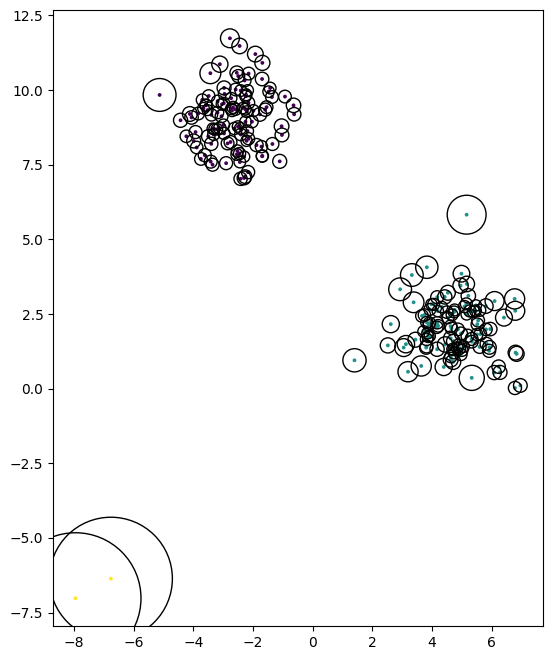

In [15]:
f, ax = plt.subplots(figsize=(14, 8))
ax.scatter(data[:,0], data[:,1], c=labels, s=3)
ax.set_aspect(1)
for i in range(len(my_lof_scores)):
    ax.add_artist(plt.Circle(tuple(data[i]), my_lof_scores[i] / 5 , fill = False))

# 2. Isolation Forest
Next we will implement the Isolation Forest.

Again, we will use a dataset, which is created below.

In [16]:
rng = np.random.default_rng(seed=42)

# data to build forest on
data = rng.normal(loc=[2, 5, 2, 5], scale=2, size=[400, 4])
outliers = rng.normal(loc=[2, 0, 2, 0], scale=2, size=[10, 4])

# data to test with
testdata = np.vstack((rng.normal(loc=[2, 5, 2, 5], scale=2, size=[200, 4]),
                     rng.normal(loc=[2, 0, 2, 0], scale=2, size=[20, 4])))

## Implementing
Below is some skeleton code which is left for you to implement the isolation forest

In [17]:
class iTree:
    def __init__(self, D, e, l):
        """
        constructs an isolation tree given the input parameters:

        :D: is the dataset
        :e: is the current path length
        :l: is the maximum path length
        """
        self.size = D.shape[0]
        self.e = e

        if self.size <= 1 or e >= l:
            self.q = None
            self.p = None
            self.left = None
            self.right = None
            return

        self.q = np.random.randint(D.shape[1])
        col = D[:, self.q]

        if np.all(col == col[0]):
            self.q = None
            self.p = None
            self.left = None
            self.right = None
            return

        self.p = np.random.uniform(np.min(col), np.max(col))

        D_left = D[col < self.p]
        D_right = D[col >= self.p]

        self.left = iTree(D_left, e + 1, l)
        self.right = iTree(D_right, e + 1, l)
    def test(self, o, pl = 0):
        """
        test the datapoint :o: against this tree, returns the path length
        """
        if self.q is None or self.left is None or self.right is None:
            return pl
        if o[self.q] < self.p:
            return self.left.test(o, pl + 1)
        else:
            return self.right.test(o, pl + 1)


In [18]:
class iForest:
    def __init__(self, D, t, phi):
        """
        Constructs an Isolation Forest given the input parameters:

        :D: the dataset
        :t: number of isolation trees
        :phi: size of subset to take from D
        """
        self.trees = []
        self.phi = phi
        for _ in range(t):
            idx = np.random.choice(D.shape[0], phi, replace=False)
            D_sub = D[idx]
            max_depth = int(np.ceil(np.log2(phi)))
            self.trees.append(iTree(D_sub, 0, max_depth))


    def test(self, o):
        """
        Tests the given datapoint :o: on the isolation trees and returns the average path length.
        """
        path_lengths = np.array([tree.test(o) for tree in self.trees])
        return np.mean(path_lengths)

## Tainted vs. Untainted Datasets
- Build the isolation forest on both the untainted and the tainted dataset (for the tainted dataset just combine the data and outliers, don't use the test data)
- Plot the ROC curves for both isolation forests. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html for a function to calculate the ROC curve. Note that we take anomalies as the positive class.
1. Does it significantly affect the performance of the isolation forest? Shortly explain why it does or it doesn't.

## Answer
No, it does not significantly affect the performance, however it degrade it slightly, as seen from the ROC curve. Both perform well burt the clean one reaches perfect TPR with fewer FPs.

In [19]:
#from sklearn.metrics import roc_curve

## Task: Understanding the hyperparameters
2. Play around with the hyperparameters. How small / large can you subsample before your performance starts to decrease? Why? How many trees do you need in the forest?

## Answer
I've run a quick test over a grid of hyperparameter values and it can be observed that performance improves with increasing subsample size fi, stabilizing after fi = 32 and t = 10, as expected as larger samples should allow more reliable splits up to a certain degree. When using few trees or very small samples, tainted forests can benefit from having outliers “in view” during training. This seems to help them more consistently isolate similar outliers, or maybe is just due to high variance of having few trees. As phi and t grow, the clean forest typically regains and maintains superior performance due to its better modeling of the true normal distribution.

auc clean  0.969125
auc tainted  0.9293750000000001


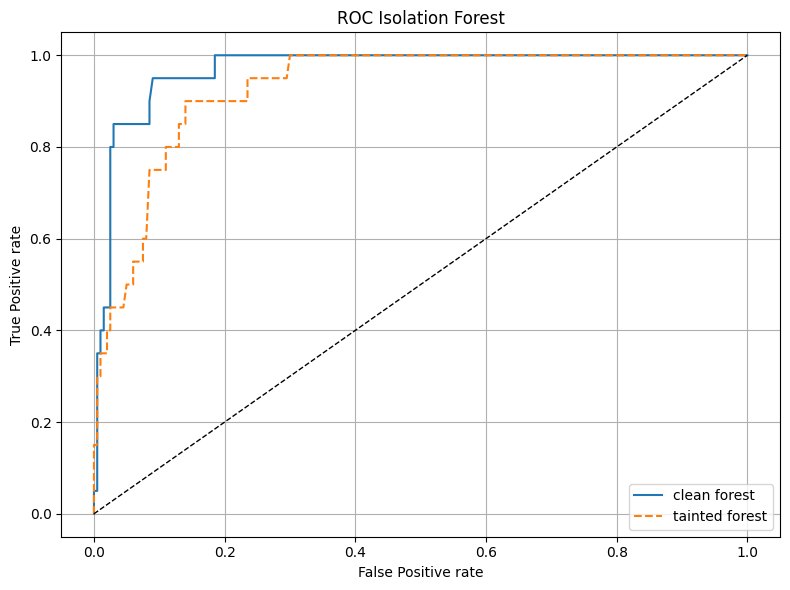

In [20]:
testlabels = np.array([0] * 200 + [1] * 20)

#train 2 forest and compare
phi = 256
t = 100

forest_clean = iForest(data, t=t, phi=phi)
forest_tainted = iForest(np.vstack((data, outliers)), t=t, phi=phi)
#test
scores_clean = -np.array([forest_clean.test(x) for x in testdata])
scores_tainted = -np.array([forest_tainted.test(x) for x in testdata])
#ROC
fpr_clean, tpr_clean, _ = roc_curve(testlabels, scores_clean)
fpr_tainted, tpr_tainted, _ = roc_curve(testlabels, scores_tainted)
#auc
auc_clean = auc(fpr_clean, tpr_clean)
auc_tainted = auc(fpr_tainted, tpr_tainted)
print(f"auc clean ", auc_clean )
print(f"auc tainted ", auc_tainted)
# plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_clean, tpr_clean, label=f"clean forest")
plt.plot(fpr_tainted, tpr_tainted, label=f"tainted forest", linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.title("ROC Isolation Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
#to explore the hyperparameter space i ve rewritten the previous code as a function and i ll call it over a selection of values. I ll use auc since i dont want to compare plots and it consider the area of the roc anyway

def if_experiment(data, outliers, testdata, testlabels, t=100, phi=256):

    forest_clean = iForest(data, t=t, phi=phi)
    forest_tainted = iForest(np.vstack((data, outliers)), t=t, phi=phi)

    scores_clean = -np.array([forest_clean.test(x) for x in testdata])
    scores_tainted = -np.array([forest_tainted.test(x) for x in testdata])

    # ROC and AUC
    fpr_clean, tpr_clean, _ = roc_curve(testlabels, scores_clean)
    fpr_tainted, tpr_tainted, _ = roc_curve(testlabels, scores_tainted)

    auc_clean = auc(fpr_clean, tpr_clean)
    auc_tainted = auc(fpr_tainted, tpr_tainted)

    print(f"AUC (clean):   {auc_clean:.4f}")
    print(f"AUC (tainted): {auc_tainted:.4f}")

    return auc_clean, auc_tainted

In [22]:
phis = [8, 16, 32, 64, 128, 256]
trees = [1, 5, 10, 25, 50, 100]
testlabels = np.array([0] * 200 + [1] * 20)

results = []

for phi in phis:
    for t in trees:
        print(f"\nTesting phi = {phi}, t = {t}")
        auc_clean, auc_tainted = if_experiment(
            data, outliers, testdata, testlabels,
            t=t, phi=phi
        )
        results.append({
            'phi': phi,
            't': t,
            'auc_clean': auc_clean,
            'auc_tainted': auc_tainted
        })


Testing phi = 8, t = 1
AUC (clean):   0.3925
AUC (tainted): 0.4150

Testing phi = 8, t = 5
AUC (clean):   0.4831
AUC (tainted): 0.3927

Testing phi = 8, t = 10
AUC (clean):   0.9483
AUC (tainted): 0.5192

Testing phi = 8, t = 25
AUC (clean):   0.9419
AUC (tainted): 0.7420

Testing phi = 8, t = 50
AUC (clean):   0.9560
AUC (tainted): 0.9587

Testing phi = 8, t = 100
AUC (clean):   0.8825
AUC (tainted): 0.9220

Testing phi = 16, t = 1
AUC (clean):   0.4595
AUC (tainted): 0.8902

Testing phi = 16, t = 5
AUC (clean):   0.8135
AUC (tainted): 0.8293

Testing phi = 16, t = 10
AUC (clean):   0.7264
AUC (tainted): 0.6550

Testing phi = 16, t = 25
AUC (clean):   0.8066
AUC (tainted): 0.7868

Testing phi = 16, t = 50
AUC (clean):   0.8782
AUC (tainted): 0.8849

Testing phi = 16, t = 100
AUC (clean):   0.7981
AUC (tainted): 0.9370

Testing phi = 32, t = 1
AUC (clean):   0.4530
AUC (tainted): 0.8013

Testing phi = 32, t = 5
AUC (clean):   0.8262
AUC (tainted): 0.8826

Testing phi = 32, t = 10
AUC 

## Task: Building a detector
We now have an isolation forest which can give a measure of anomalousness for a given datapoint. But how are we going to use it to detect anomalies?

3. Using a threshold, create a detector which given a datapoint indicates whether it is anomalous or not. It should return a 1 if it is an anomaly, and a 0 if it is normal data.
    - NOTE: Motivate why you choose your threshold using metrics
    
## Answer
I'll use Matthew Correlation Coefficient as it's a very solid metric for binary classification especially when classes are unbalanced as in the case of anomalies.  According to:

> Chicco D, Jurman G. "The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation"

The MCC is the most informative metric to assess performance in binary classification tasks.

I'll try to max the MCC to get the optimal threshold.

In [23]:
def detect(datapoint, threshold):
    """
    Returns 1 if the given datapoint is an anomaly, 0 otherwise.
    """
    score = -forest.test(datapoint)
    return int(score > threshold)

In [24]:
def find_best_threshold_mcc(scores, labels):
    """
    getting the score threshold that maximizes the MCC.
    """
    thresholds = np.unique(scores)
    best_mcc = -1
    best_threshold = thresholds[0]

    for thresh in thresholds:
        preds = (scores > thresh).astype(int)
        mcc = matthews_corrcoef(labels, preds)
        if mcc > best_mcc:
            best_mcc = mcc
            best_threshold = thresh

    return best_threshold, best_mcc

In [25]:
forest = iForest(data, t=100, phi=256)

scores = -np.array([forest.test(x) for x in testdata])

# i try to get optimal threshold using MCC
threshold, best_mcc = find_best_threshold_mcc(scores, testlabels)
print(f"Best threshold: {threshold:.4f}, MCC = {best_mcc:.3f}")


predictions = (scores > threshold).astype(int)



print(classification_report(testlabels, predictions, digits=3))


Best threshold: -7.0200, MCC = 0.686
              precision    recall  f1-score   support

           0      0.984     0.945     0.964       200
           1      0.607     0.850     0.708        20

    accuracy                          0.936       220
   macro avg      0.796     0.897     0.836       220
weighted avg      0.950     0.936     0.941       220



## Task: Evaluate
Now we want to evaluate the performance of your detector.
- Calculate the True Positive Rate, False Positive Rate, and Precision for your detector based on the output of the confusion matrix. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix for how to use the function, and see https://en.wikipedia.org/wiki/Confusion_matrix for how to calculate the metrics.
   - NOTE: do NOT use some other convenience function from sklearn or elsewhere to calculate these metrics. These may only be used to validate your metrics. <- i just did it like this :(

4. Are you happy with the performance of the model? Why or why not?

## Answer
The model performs well having used both a strong metric and optimized the threashold in its function. Recall is lower than expected as missing one third of anomalies is more than auspicable. In a irl context having more false positives to make up for the false negatives could be a good idea, as usually the cost of misclassification differ. The classes being very uneven might still be a difficulty and data-processing techniques could be tried to improve the result.

In [26]:
predictions = np.array([detect(x, threshold) for x in testdata])

In [27]:
cm = confusion_matrix(testlabels, predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[189  11]
 [  3  17]]


In [28]:
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

R = TP / (TP + FN) if (TP + FN) > 0 else 0

FPR = FP / (FP + TN) if (FP + TN) > 0 else 0


Precision = TP / (TP + FP) if (TP + FP) > 0 else 0


print(f"Recall {R}")
print(f"False Positive Rate (FPR): {FPR}")
print(f"Precision: {Precision:.2f}")

Recall 0.85
False Positive Rate (FPR): 0.055
Precision: 0.61


In [29]:
#from sklearn.metrics import confusion_matrix

# 3. Machine Learning for Temporal Anomaly Detection
We will now look at the case of temporal data. For temporal data, it is possible to use any conventional Machine Learning model in order to perform anomaly detection. We start by creating a simple dataset below. We inject an anomaly towards the end of the dataset which will be included in the test dataset.

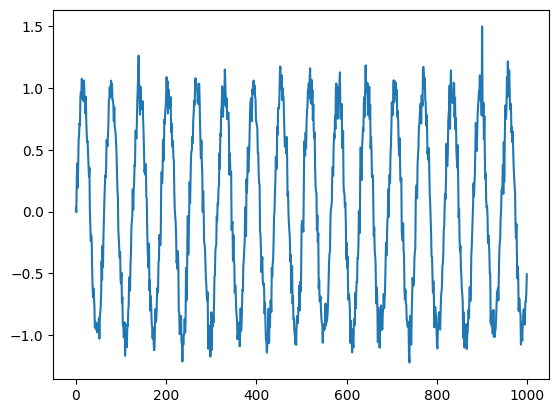

In [30]:
rng = np.random.default_rng(seed=42)
y = np.sin(np.arange(0, 100, 0.1)) + rng.normal(loc=0, scale=0.1, size=1000)
y[900] = 1.5
train = y[:800]
test = y[800:]
plt.plot(y)

## Question
I have created this simple dataset by using a sine function and adding some gaussian-distributed noise.
1. Is this training dataset tainted or untainted? Explain why or why not.

## Answer
The train set stops at index 800 and the anomaly is introduced after that, the dataset is untaited as it only contains the "normal" behavior and not any anomalies.


## Task: Set up the training
We will use a ML algorithm with a sliding window to try and predict the next value based on the last 24.
- transform the train and test datasets into appropriate shapes to train the model
- the model should take the last 24 datapoints (X) to predict the next datapoint (Y)
- use a stride / stepsize of 1

In [38]:
train_x = []
train_y = []

for i in range(len(train) - 24):
    train_x.append(train[i:i+ 24])
    train_y.append(train[i + 24])

test_x = []
test_y = []

for i in range(len(test) - 24):
    test_x.append(test[i:i+ 24])
    test_y.append(test[i + 24])

## Task: Train the model
Now that we have the datasets set up properly, we can train our model. Let's use a random forest regressor.
- Train the random forest regressor on the train dataset
- Use the trained random forest regressor to make predictions on the test dataset

In [41]:
#from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_x, train_y)
predictions = model.predict(test_x)


## Task: Plot your predictions
Let's see visually how the model performs.
- Plot the predictions of your model against the actual values.
2. Does your model perform well?
3. Do you think it matters for this set-up if the training dataset is tainted or untainted? Why?

## Answer
2. The mean squared error is very small, so on average there is a only small prediction errors. Visually, the predicted values closely follow the actual signal, including the periodic structure and noise. The only cler deviation occurs at the anomaly insertion, which is expected and useful for detecting it.
3. If the training dataset is tainted (contain anomalies), the model may learn to treat abnormal patterns as normal behavior, reducing its sensitivity to detect anomalies. Our model is trained to predict normal behavior, an untainted dataset ensures it learns only the true underlying pattern (sine wave + noise), making it easier to spot eventual deviations.

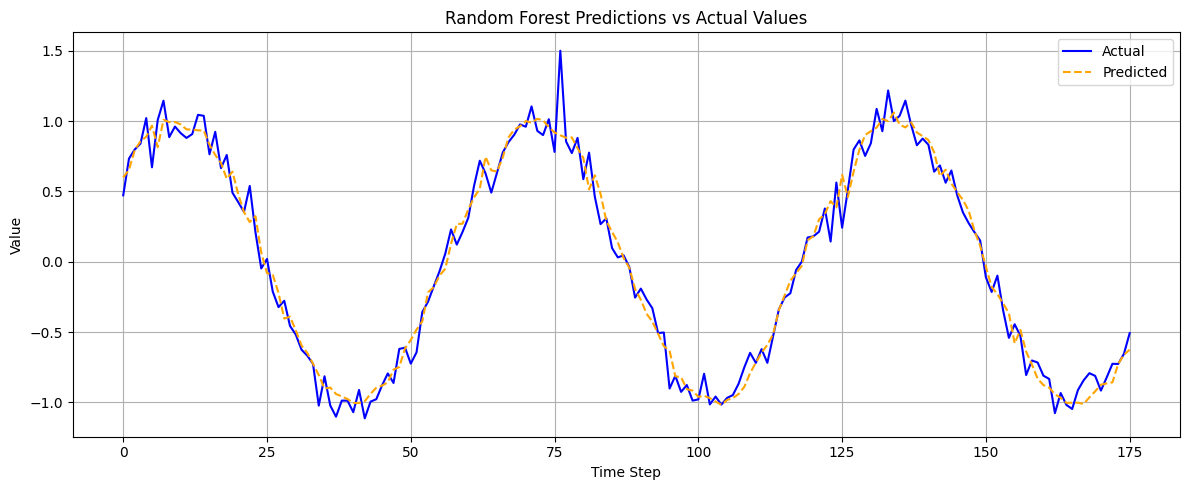

Mean Squared Error:0.0140


In [45]:
plt.figure(figsize=(12, 5))

plt.plot(test_y, label="Actual", color='blue')
plt.plot(predictions, label="Predicted", color='orange', linestyle='--')

plt.title("Random Forest Predictions vs Actual Values")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mse = mean_squared_error(test_y, predictions)
print(f"Mean Squared Error:{mse:.2f}")

## Task: plot the prediction residual.
To actually detect the anomalies, we need to calculate the residual.
- Calculate the residual and plot it.
4. Does the residual look useful for detecting anomalies?
- Check if the injected anomaly can be detected using your residual score without giving any false positives (you should be able to motivate this via the plot, you do not need to write code for this)

## Answer
4. Yes, it is useful. It can be used as a metric by setting a treshold of residuals after which everything is considered an anomaly. By tweaking this threshold one can isolate the anomaly and achieve perfect classification (check the graph)

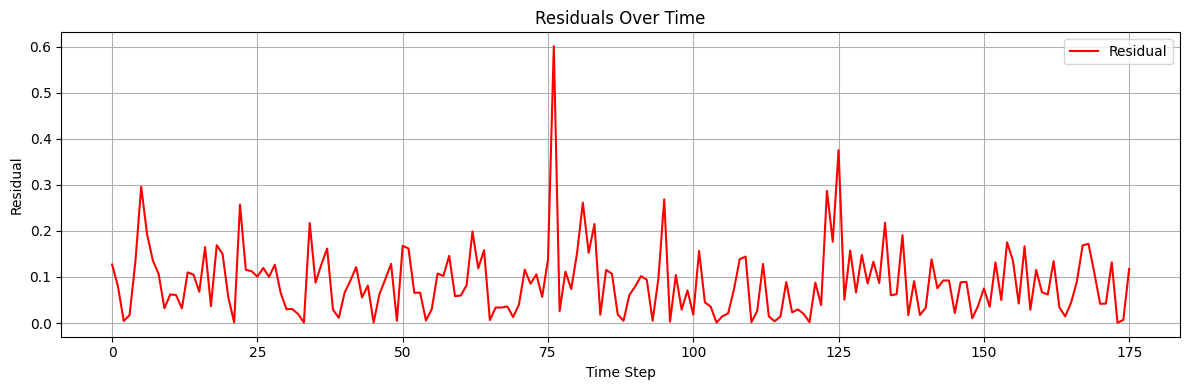

In [47]:
residuals = np.abs(test_y - predictions) #is the premade function fine? can be computed manually but...
plt.figure(figsize=(12, 4))
plt.plot(residuals, label="Residual", color="red")
plt.title("Residuals Over Time")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Autoencoder for Anomaly Detection
Lastly, we will use an autoencoder on the same temporal dataset to detect anomalies. Although we will use it now in a temporal setting, note that autoencoders can also be used to detect anomalies in non-temporal data.

In [33]:
#import torch

## Task: Create train / test dataset
We will use the autoencoder slightly differently. Let's pretend that this dataset is the temperature at our nuclear reactor. We take a measurement every hour and we upload this data once per day to our server, at which point we use the autoencoder to detect anomalies.
- transform the train and test datasets into appropriate shapes to train the model
- the model should take a window of 24 datapoints and reconstruct it.
- The stride should be 24.

In [49]:
train_x = []
for i in range(0, len(train) - 24 + 1, 24):
    window = train[i:i + 24]
    train_x.append(window)

test_x = []
for i in range(0, len(test) - 24 + 1, 24):
    window = test[i:i + 24]
    test_x.append(window)

## Task: Train the autoencoder
Below I have provided a simple autoencoder class which you can use.
- Use the MSE loss and the Adam optimizer to train an autoencoder on the training dataset you created.

In [35]:
class Autoencoder(torch.nn.Module):
    def __init__(self, latent_nodes):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(24, 15),
            torch.nn.ReLU(),
            torch.nn.Linear(15, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, latent_nodes)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_nodes, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 15),
            torch.nn.ReLU(),
            torch.nn.Linear(15, 24)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [36]:
#model = None
#loss_fn = None
#optimizer = None

In [54]:
#encoder training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_tensor = torch.tensor(train_x, dtype=torch.float32).to(device)
model = Autoencoder(latent_nodes=8).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
epochs = 300

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(train_tensor)
    loss = loss_fn(outputs, train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 1/300, Loss: 0.545619
Epoch 10/300, Loss: 0.535742
Epoch 20/300, Loss: 0.526496
Epoch 30/300, Loss: 0.517324
Epoch 40/300, Loss: 0.506329
Epoch 50/300, Loss: 0.493476
Epoch 60/300, Loss: 0.475752
Epoch 70/300, Loss: 0.445559
Epoch 80/300, Loss: 0.396813
Epoch 90/300, Loss: 0.334660
Epoch 100/300, Loss: 0.284763
Epoch 110/300, Loss: 0.250330
Epoch 120/300, Loss: 0.227665
Epoch 130/300, Loss: 0.213998
Epoch 140/300, Loss: 0.205948
Epoch 150/300, Loss: 0.201216
Epoch 160/300, Loss: 0.198270
Epoch 170/300, Loss: 0.196341
Epoch 180/300, Loss: 0.195032
Epoch 190/300, Loss: 0.193774
Epoch 200/300, Loss: 0.192395
Epoch 210/300, Loss: 0.190624
Epoch 220/300, Loss: 0.187604
Epoch 230/300, Loss: 0.183065
Epoch 240/300, Loss: 0.174553
Epoch 250/300, Loss: 0.156818
Epoch 260/300, Loss: 0.126630
Epoch 270/300, Loss: 0.089693
Epoch 280/300, Loss: 0.056463
Epoch 290/300, Loss: 0.032475
Epoch 300/300, Loss: 0.021057


## Task: Plotting
Once you have achieved a loss you are happy with (should be below or around 0.02), apply the autoencoder to the test dataset and plot the reconstructed data.
Next, plot the reconstruction error on the test dataset.
1. Is the reconstruction error useful to detect the anomaly?
2. Which approach do you prefer for temporal data: to use ML to predict next values, or to use an autoencoder to reconstruct the data? Why?
3. There are a couple of hyperparameters which you had to figure out to train an accurate model (number of nodes in latent space, learning rate, number of epochs). Describe how the number of nodes in the autoencoder affects the performance of the model using plots. (You do not need to investigate the other hyperparameters)

## Answer
1. From the plot it can be seen that the reconstruction error spikes at window index 4, which is where the injected anomaly is. The other windows have lower and consistent error, making this spike easy to isolate using a threshold. As predicted the difficulty of autoencoders in reconstructing anomalous patterns can be exploited.
2. Personally I preferred the ML approach as it's more intuitive and allows human users to easily interface with it, autoencoders are probably more performing as their strong suit is to learn general structures robustly and generalizing normal behavior.
3. I've kept the default learning rate that comes with Adam (1e-3). Regarding epochs I've seen that the model was still learning from 90 to 100, so i increased to 200 and repeated. 300 showed less improvement from 290 while consistently achieving required performance (.02). After running some tests, from the plots at the end of this notebook it can be seen that few (< 4) nodes performs better. Worst performance is achieved by 4 nodes, while beyond that the anomaly can still be detected at eyesight. While I don't know the exact reason for this behavior, fewer nodes being better makes sense theoretically as having to many nodes might cause the model to learn better also the anomalous behavior.

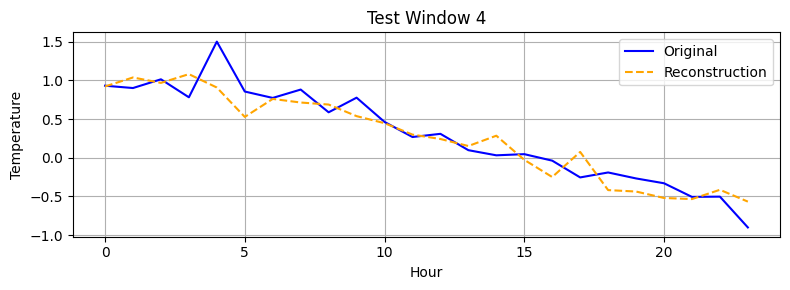

MAE for test window 4: 0.1669


In [69]:

test_tensor = torch.tensor(test_x, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    reconstructions = model(test_tensor).cpu().numpy()

i = 4  #this is the window with anomaly, can be changed to see the others

plt.figure(figsize=(8, 3))
plt.plot(test_x[i], label='Original', color='blue')
plt.plot(reconstructions[i], label='Reconstruction', color='orange', linestyle='--')
plt.title(f"Test Window {i}")
plt.xlabel("Hour")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


mae = mean_absolute_error(test_x[i], reconstructions[i])
print(f"MAE for test window {i}: {mae:.4f}") #note mae is greater when anomaly is introduced

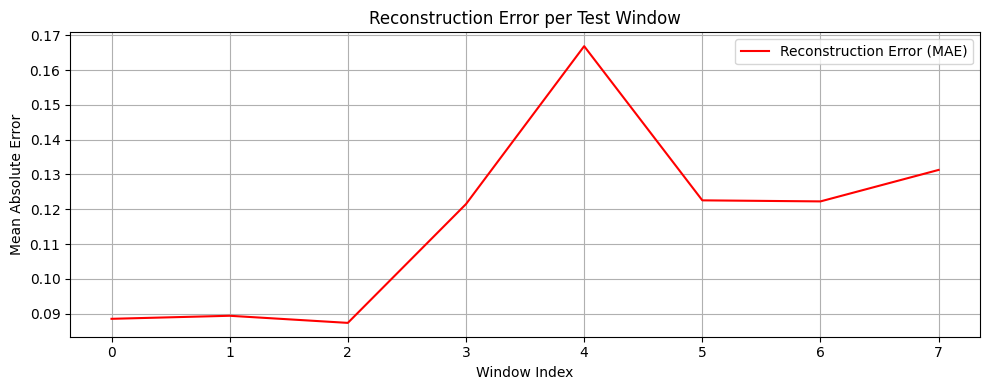

In [71]:
reconstruction_error = [
    mean_absolute_error(original, reconstructed)
    for original, reconstructed in zip(test_x, reconstructions)
]

plt.figure(figsize=(10, 4))
plt.plot(reconstruction_error, label='Reconstruction Error', color='red')
plt.title("Reconstruction Error per test window")
plt.xlabel("Window index")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Training aqutoencoder with 2 latent nodes ---
Average MAE on test set: 0.1049


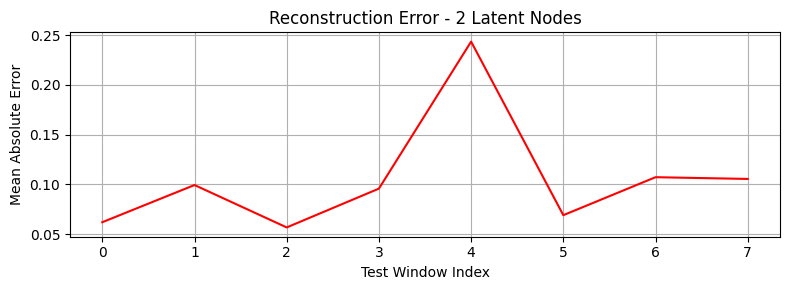


--- Training aqutoencoder with 4 latent nodes ---
Average MAE on test set: 0.0923


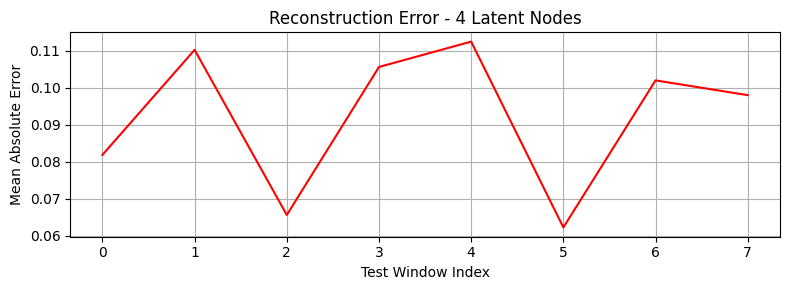


--- Training aqutoencoder with 8 latent nodes ---
Average MAE on test set: 0.0796


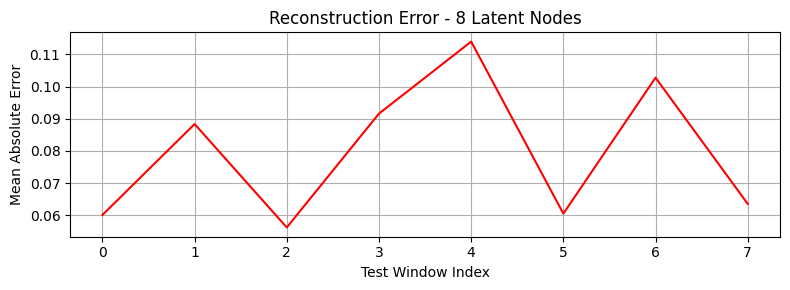


--- Training aqutoencoder with 12 latent nodes ---
Average MAE on test set: 0.0873


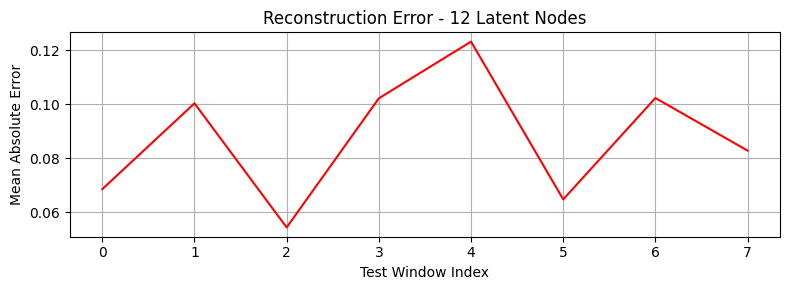


--- Training aqutoencoder with 16 latent nodes ---
Average MAE on test set: 0.0849


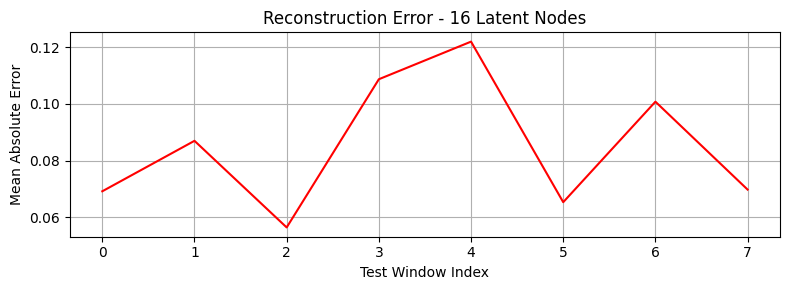

In [72]:
# Prepare data
train_tensor = torch.tensor(train_x, dtype=torch.float32).to(device)
test_tensor = torch.tensor(test_x, dtype=torch.float32).to(device)

latent_dims = [2, 4, 8, 12, 16]
epochs = 300

for latent_nodes in latent_dims:
    print(f"\n--- Training aqutoencoder with {latent_nodes} latent nodes ---")

    model = Autoencoder(latent_nodes=latent_nodes).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters())

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_tensor)
        loss = loss_fn(outputs, train_tensor)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        reconstructions = model(test_tensor).cpu().numpy()

    reconstruction_error = [
        mean_absolute_error(orig, recon)
        for orig, recon in zip(test_x, reconstructions)
    ]

    avg_mae = sum(reconstruction_error) / len(reconstruction_error)
    print(f"Average MAE on test: {avg_mae:.4f}")

    plt.figure(figsize=(8, 3))
    plt.plot(reconstruction_error, color='red')
    plt.title(f"Reconstruction eror - {latent_nodes} latent nodes")
    plt.xlabel("Test window index")
    plt.ylabel("Mean Absolute Error")
    plt.grid(True)
    plt.tight_layout()
    plt.show()